<a href="https://colab.research.google.com/github/Polyanat59/Trab_preparacao_de_dados/blob/main/preparacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
import datetime as dt

In [41]:
sns.set(style="whitegrid")

In [42]:
lojas = []
for i in range(1, 5):
    df = pd.read_csv(f"loja_{i}.csv")
    df["loja"] = f"Loja {i}"
    lojas.append(df)

# Unificar
dados = pd.concat(lojas, ignore_index=True)


In [43]:
# Padronizar colunas
dados.columns = (
    dados.columns.str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("ã", "a")
    .str.replace("ç", "c")
    .str.replace("é", "e")
)
print("Colunas ", dados.columns.tolist())

Colunas  ['produto', 'categoria_do_produto', 'preco', 'frete', 'data_da_compra', 'vendedor', 'local_da_compra', 'avaliacao_da_compra', 'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon', 'loja']


In [44]:
# converte as colunas numericas
numeric_cols = ["preco", "frete", "avaliacao_da_compra"]
for col in numeric_cols:
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

In [45]:
# Remover linhas sem preco/frete
dados = dados.dropna(subset=["preco", "frete"])

In [46]:
print(dados.columns.tolist())


['produto', 'categoria_do_produto', 'preco', 'frete', 'data_da_compra', 'vendedor', 'local_da_compra', 'avaliacao_da_compra', 'tipo_de_pagamento', 'quantidade_de_parcelas', 'lat', 'lon', 'loja']


In [47]:
dados.head()

,produto,categoria_do_produto,preco,frete,data_da_compra,vendedor,local_da_compra,avaliacao_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [48]:
#Coluna faturamento
dados["faturamento"] = dados["preco"] + dados["frete"]
dados.head()

,produto,categoria_do_produto,preco,frete,data_da_compra,vendedor,local_da_compra,avaliacao_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,loja,faturamento
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1,228.329790
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1,267.584305
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1,300.772681
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1,1064.657344
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1,473.954689


Top 5 Categorias por Faturamento Total:
categoria_do_produto
eletronicos              R$ 2,332,048.08
eletrodomesticos         R$ 1,860,198.66
moveis                   R$ 1,064,149.77
instrumentos musicais      R$ 489,701.48
esporte e lazer            R$ 200,891.94
Name: faturamento, dtype: object


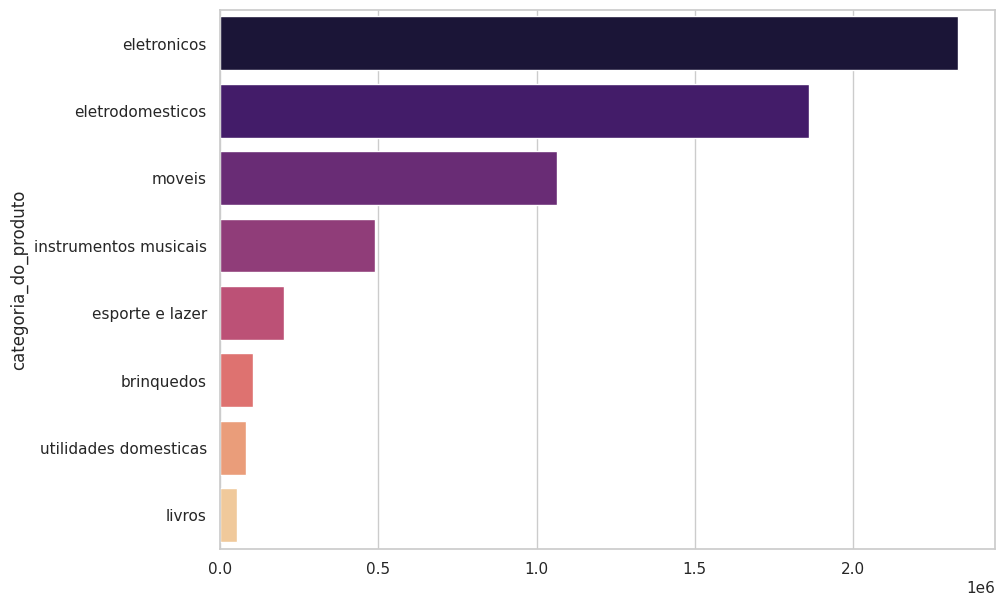

In [49]:
# Categorias mais vendidads
if "faturamento" in dados.columns and "categoria_do_produto" in dados.columns:
    cat_fat_total = dados.groupby("categoria_do_produto")["faturamento"].sum().sort_values(ascending=False)

    print("Top 5 Categorias por Faturamento Total:")
    print(cat_fat_total.head(5).apply(lambda x: f"R$ {x:,.2f}"))

    plt.figure(figsize=(10, 7))
    sns.barplot(
        x=cat_fat_total.head(10).values,
        y=cat_fat_total.head(10).index,
        hue=cat_fat_total.head(10).index,
        palette="magma",
        legend=False
    )

In [50]:
numericas = ["preco", "frete", "avaliacao_da_compra", "faturamento"]
resumo = dados[numericas].describe().round(2)
print("\nResumo estatístico:")
print(resumo)


Resumo estatístico:
         preco    frete  avaliacao_da_compra  faturamento
count  9435.00  9435.00              9435.00      9435.00
mean    622.31    33.17                 4.01       655.48
std     787.09    41.97                 1.39       828.98
min      10.07     0.00                 1.00        10.07
25%      73.61     4.01                 3.00        77.57
50%     295.35    15.65                 5.00       310.76
75%     884.40    46.59                 5.00       931.47
max    3969.38   216.71                 5.00      4181.05


/tmp/ipython-input-2170453773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="loja", y="faturamento", data=dados, palette=["tomato", "salmon", "pink", "purple"]


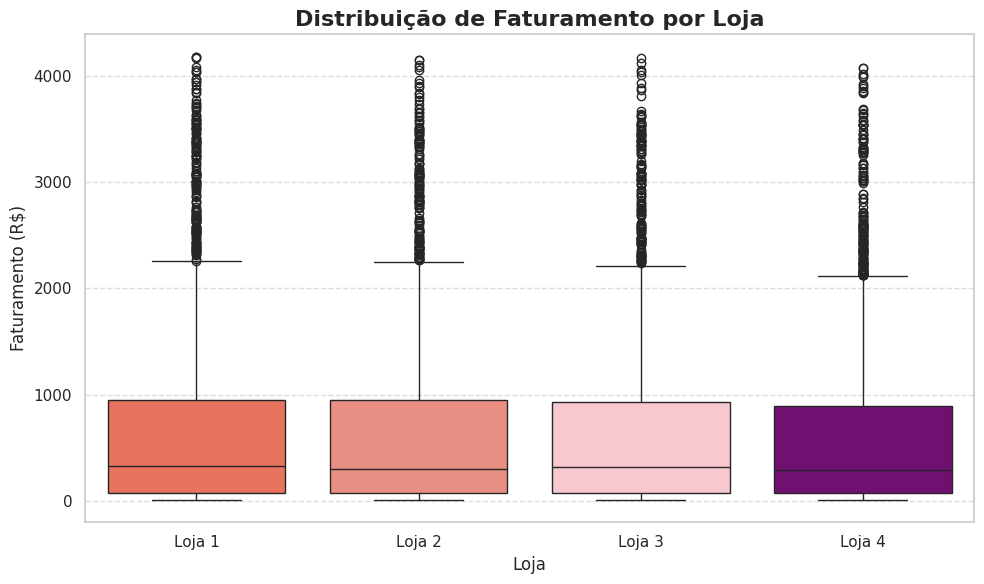

In [62]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="loja", y="faturamento", data=dados, palette=["tomato", "salmon", "pink", "purple"]
)

plt.title("Distribuição de Faturamento por Loja", fontsize=16, fontweight='bold')
plt.xlabel("Loja", fontsize=12)
plt.ylabel("Faturamento (R$)", fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

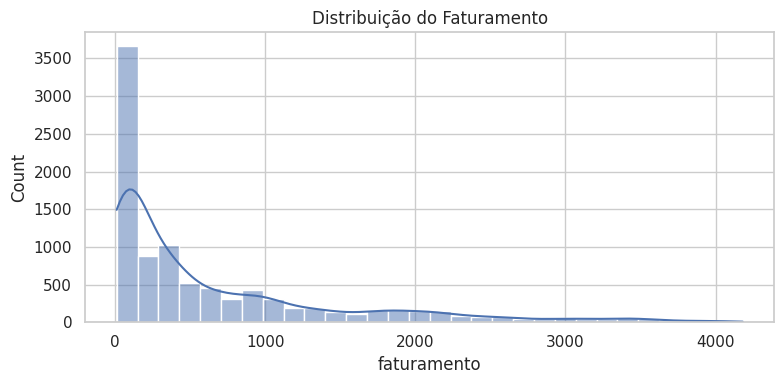

In [52]:
plt.figure(figsize=(8,4))
sns.histplot(dados["faturamento"], bins=30, kde=True)
plt.title("Distribuição do Faturamento")
plt.tight_layout()
plt.show()

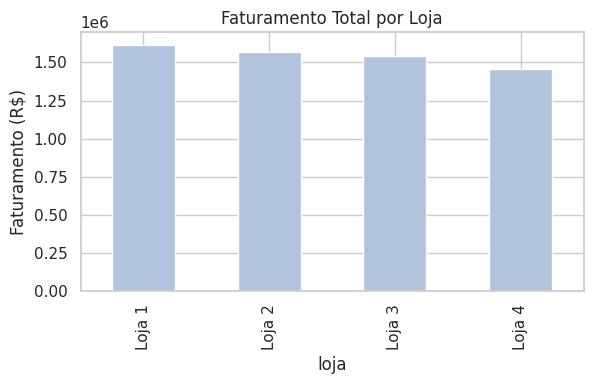

In [53]:
fat = dados.groupby("loja")["faturamento"].sum()
plt.figure(figsize=(6,4))
fat.plot(kind="bar", color="lightsteelblue")
plt.title("Faturamento Total por Loja")
plt.ylabel("Faturamento (R$)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2025523872.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dados[coluna_data] = pd.to_datetime(dados[coluna_data])


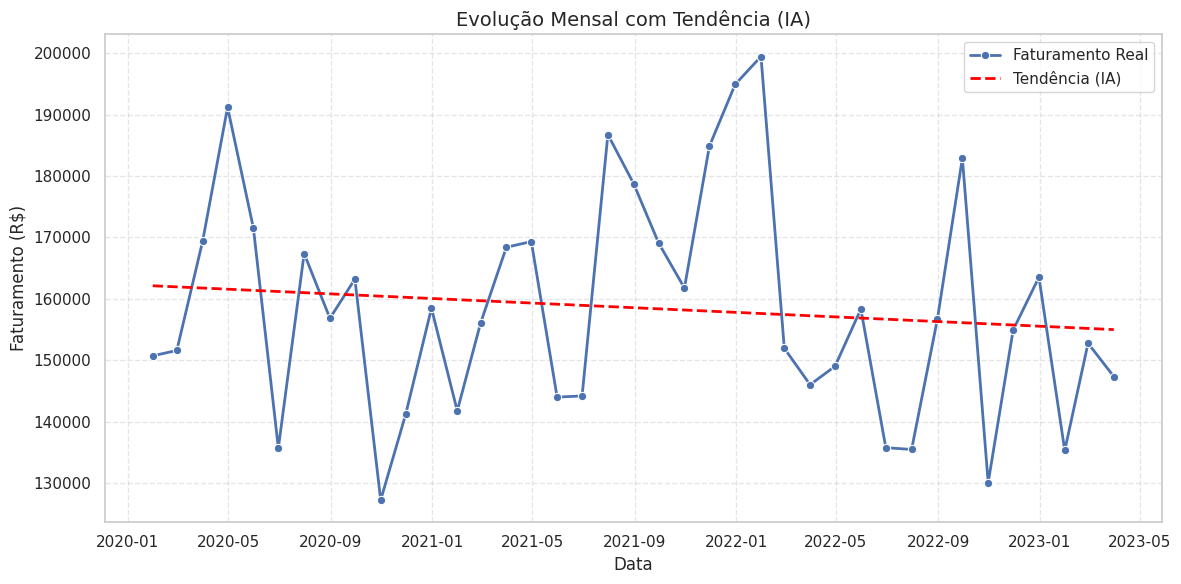

Inclinação da reta: -6.17
Conclusão: A tendência geral é de QUEDA.


In [54]:

coluna_data = 'data_da_compra'
dados[coluna_data] = pd.to_datetime(dados[coluna_data])

vendas_mensais = dados.set_index(coluna_data).resample('ME')['faturamento'].sum().reset_index()


vendas_mensais['data_numerica'] = vendas_mensais[coluna_data].map(dt.datetime.toordinal)

X = vendas_mensais[['data_numerica']]
y = vendas_mensais['faturamento']

modelo = LinearRegression()
modelo.fit(X, y)


vendas_mensais['tendencia_ia'] = modelo.predict(X)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=vendas_mensais,
    x=coluna_data,
    y='faturamento',
    label='Faturamento Real',
    marker='o',
    linewidth=2
)

plt.plot(
    vendas_mensais[coluna_data],
    vendas_mensais['tendencia_ia'],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Tendência (IA)'
)

plt.title("Evolução Mensal com Tendência (IA)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Faturamento (R$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

inclinacao = modelo.coef_[0]
print(f"Inclinação da reta: {inclinacao:.2f}")
if inclinacao > 0:
    print("Conclusão: A tendência geral é de CRESCIMENTO.")
else:
    print("Conclusão: A tendência geral é de QUEDA.")

In [57]:
# Previsão
ultima_data = vendas_mensais[coluna_data].max()

proxima_data = ultima_data + pd.offsets.MonthEnd(1)

proxima_data_ordinal = proxima_data.toordinal()

previsao_faturamento = modelo.predict(
    pd.DataFrame({"data_numerica": [proxima_data_ordinal]})
)


print("-" * 30)
print(f"Última data nos dados: {ultima_data.strftime('%d/%m/%Y')}")
print(f"Data da Previsão:      {proxima_data.strftime('%d/%m/%Y')}")
print(f"Faturamento Previsto: R$ {previsao_faturamento[0]:,.2f}")
print("-" * 30)


------------------------------
Última data nos dados: 31/03/2023
Data da Previsão:      30/04/2023
Faturamento Previsto: R$ 154,825.40
------------------------------
